### MODELO RANDOM FOREST

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

# To save models
import json
import pickle

# Feature Selection
from sklearn.feature_selection import f_classif, SelectKBest

# Modelado
from sklearn.ensemble import RandomForestClassifier

# Métricas
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score
from sklearn.metrics import recall_score, f1_score, ConfusionMatrixDisplay
from sklearn.metrics import roc_auc_score, roc_curve

# Optimizar
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import TimeSeriesSplit

# from tqdm import tqdm
import warnings
import zipfile
import os

from utils import get_classifier_metrics

In [2]:
def warn(*args, **kwargs):
    pass

warnings.warn = warn

In [ ]:
# Lectura directa desde los archivos
X_train = pd.read_csv('../data/processed/X_train_temporal_obj1.csv')
X_test = pd.read_csv('../data/processed/X_test_temporal_obj1.csv')
y_train = pd.read_csv('../data/processed/y_train_temporal_obj1.csv')
y_test = pd.read_csv('../data/processed/y_test_temporal_obj1.csv')

# Tip: Si el CSV tiene un nombre distinto dentro del zip, 
# pandas suele detectarlo automáticamente si solo hay uno.

In [ ]:
X_train.shape

(496369, 19)

In [ ]:
X_test.shape

(123726, 19)

In [ ]:
y_train.shape

(496369, 1)

In [ ]:
y_test.shape

(123726, 1)

In [ ]:
# Eliminar columna de índice sobrante si existe.
for df_temp in [X_train, X_test]:
    if 'Unnamed: 0' in df_temp.columns:
        df_temp.drop(columns=['Unnamed: 0'], inplace=True)


In [ ]:
# Reviso que no haya valores nulos con la nueva carga de archivo.

# Lista de tus variables cargadas
datasets = {'X_train': X_train,'X_test': X_test,'y_train': y_train, 'y_test': y_test}

for nombre, df_actual in datasets.items():
    if df_actual is not None:
        total_nulos = df_actual.isnull().sum().sum() # Suma total de nulos en todo el dataframe
        print(f'{nombre}: {total_nulos} nulos encontrados.')
        
        # Si hay nulos, mostramos en qué columnas están
        if total_nulos > 0:
            df_actual.isnull().sum()[df_actual.isnull().sum() > 0]
            
    else:
        f'{nombre}: No está cargado (es None).'

X_train: 0 nulos encontrados.
X_test: 0 nulos encontrados.
y_train: 0 nulos encontrados.
y_test: 0 nulos encontrados.


In [10]:
model_forest_clas = RandomForestClassifier(n_estimators=100,    # Número de árboles
                                           max_depth=5,        # Limitamos la profundidad para evitar overfitting
                                           class_weight='balanced', 
                                           min_samples_leaf=100,  # Cada decisión debe basarse en muchos datos
                                           random_state=42,
                                           n_jobs=-1)
model_forest_clas.fit(X_train, y_train)

c:\Users\Usuario\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


,n_estimators,100
,criterion,'gini'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,100
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [11]:
y_pred_test = model_forest_clas.predict(X_test)
y_pred_train = model_forest_clas.predict(X_train)

In [13]:
get_classifier_metrics(y_pred_test, y_test, y_pred_train, y_train)

,Accuracy,F1 Score,Precision,Recall
Train set,0.520568,0.520568,0.520568,0.520568
Test set,0.506846,0.506846,0.506846,0.506846


In [14]:
get_classifier_metrics(y_pred_test, y_test, y_pred_train, y_train, average='weighted')

,Accuracy,F1 Score,Precision,Recall
Train set,0.520568,0.520696,0.520963,0.520568
Test set,0.506846,0.507052,0.507390,0.506846


Top 15 variables más importantes:
            Variable  Importancia
18            Ticker     0.351597
15         RSI_lag_1     0.092152
6        BB_Position     0.086421
9       Volume_Ratio     0.077767
5                RSI     0.073302
8       Price_Change     0.055098
11      Volume_lag_2     0.035814
2             EMA_12     0.027875
10      Volume_lag_1     0.023912
14     Volume_lag_10     0.021146
7         Volatility     0.020115
13      Volume_lag_5     0.019839
17  Volatility_lag_1     0.018035
12      Volume_lag_3     0.017023
0              Close     0.016810


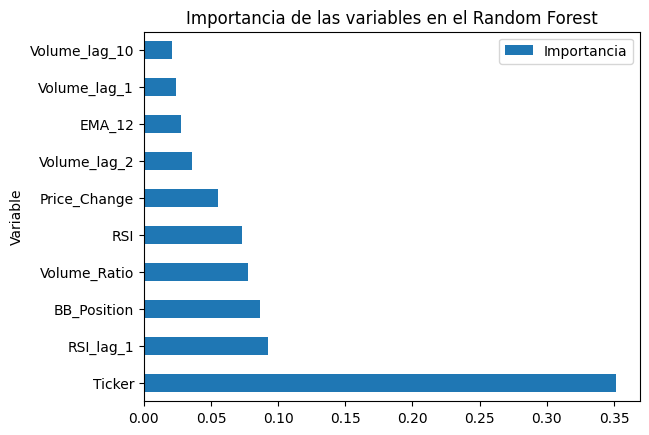

In [ ]:
# Extraer importancia de las variables
# esto es para ver qué está mirando el modelo realmente
importancias = pd.DataFrame({'Variable': X_train.columns,
                             'Importancia': model_forest_clas.feature_importances_}).sort_values(by='Importancia', ascending=False)

#Top 15 variables más importantes:
importancias.head(15)

In [ ]:
# Graficar
importancias.head(10).plot(kind='barh', x='Variable', y='Importancia')
plt.title('Importancia de las variables en el Random Forest')
plt.show()

### Conclusión:
Actualmente no da buen resultado. un 50% en este tipo de proyecto no es bueno.

## Hiperparametrización

In [ ]:
# Definir hiperparámetros a probar
hparam_foreclas = {'n_estimators': [50, 100, 200],
                   'max_depth': [3, 5, 10],
                   'min_samples_split': [2, 5, 10],
                   'min_samples_leaf': [1, 2, 4, 100, 150, 200]}


# Definimos el validador temporal (evita que el modelo mire al futuro en las pruebas)
tscv = TimeSeriesSplit(n_splits=5)

# Implementar GridSearchCV
grid_search_foreclas = GridSearchCV(RandomForestClassifier(random_state=18),
                                    hparam_foreclas,
                                    cv=tscv,
                                    n_jobs=-1,
                                    verbose=1,
                                    scoring='roc_auc')

# Entrenamos
grid_search_foreclas.fit(X_train, y_train)

# Mostrar los mejores hiperparámetros encontrados
grid_search_foreclas.best_params_

Fitting 5 folds for each of 162 candidates, totalling 810 fits


c:\Users\Usuario\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


{'max_depth': 10,
 'min_samples_leaf': 100,
 'min_samples_split': 2,
 'n_estimators': 200}

In [ ]:
# Extraemos el mejor modelo ya entrenado
best_rf_model = grid_search_foreclas.best_estimator_

# Hacemos predicciones con los datos de TEST
y_pred_test = best_rf_model.predict(X_test)

# Importante: Para métricas como ROC-AUC, necesitamos las PROBABILIDADES
y_pred_probs = best_rf_model.predict_proba(X_test)[:, 1]

f'Mejor modelo listo y predicciones generadas.'

Mejor modelo listo y predicciones generadas.


ROC-AUC en Test: 0.5076


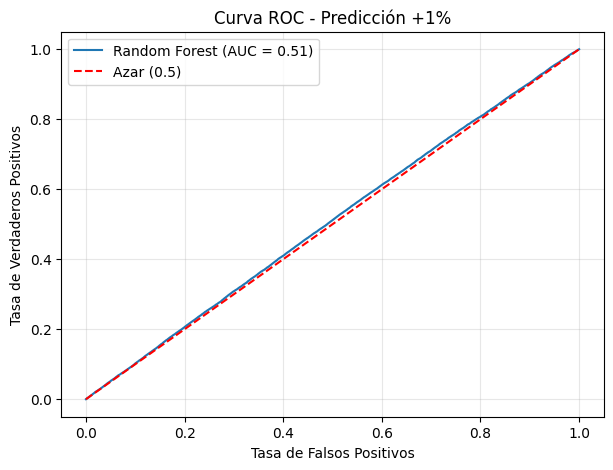

In [ ]:
# Calcular el Score
auc_test = roc_auc_score(y_test, y_pred_probs)

f'ROC-AUC en Test: {auc_test:.4f}'


In [ ]:

# Dibujar la curva
fpr, tpr, _ = roc_curve(y_test, y_pred_probs)
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f'Random Forest (AUC = {auc_test:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Azar (0.5)')
plt.title('Curva ROC - Predicción +1%')
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

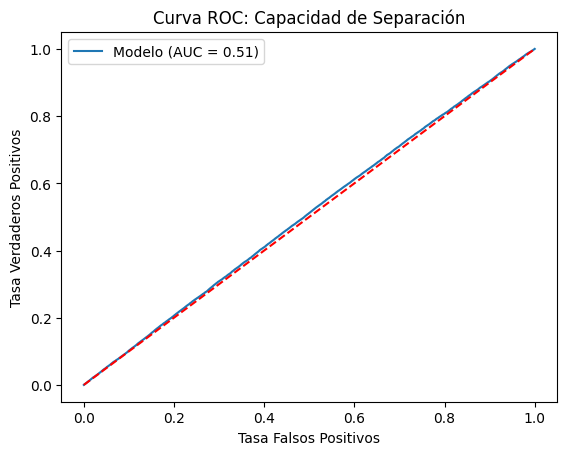

In [21]:
# Usamos probabilidades, no clases (0/1)
y_probs = grid_search_foreclas.best_estimator_.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_probs)

fpr, tpr, thresholds = roc_curve(y_test, y_probs)
plt.plot(fpr, tpr, label=f'Modelo (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], 'r--')
plt.title('Curva ROC: Capacidad de Separación')
plt.xlabel('Tasa Falsos Positivos')
plt.ylabel('Tasa Verdaderos Positivos')
plt.legend()
plt.show()

In [ ]:
#with open('../models/random_forest_clas.pkl', 'wb') as file:
#   pickle.dump(best_rf_model, file)

## Conclusión 
Este modelo solo arroja un 51%. No considero que sea bueno.

### Notas:
ROC-AUC: * Si el AUC está entre 0.50 y 0.55: El modelo es débil, casi azar. Necesitas mejores variables (indicadores técnicos).

Si el AUC está entre 0.56 y 0.65: Para trading/bolsa, ¡es un resultado muy prometedor! Es una ventaja estadística real.

##### Se aconseja haceer un nuevo EDA donde se haga ingieneria de Variables:

Ingeniería de Variables: El 'Salto de Calidad'
Tu notebook usa precios y el Ticker. Para predecir un +1%, el modelo necesita saber el 'estado de ánimo' del mercado. Si no añades indicadores, el accuracy no subirá.

Añade estas columnas antes del escalado:

Momentum: data['retorno_5d'] = data['Close'].pct_change(5) (¿Qué ha hecho la acción esta semana?)

Volatilidad: data['volatilidad_10d'] = data['Close'].rolling(10).std() (¿Está el mercado nervioso?)

RSI (Fuerza Relativa): Indica si la acción está sobrecomprada o sobrevendida.